In [737]:
#Importing libraries
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np 
import sqlite3
from sklearn.model_selection import train_test_split, GridSearchCV,cross_validate, cross_val_predict, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score, recall_score, confusion_matrix,roc_auc_score,classification_report

In [738]:
#load the dataset
data=pd.read_csv('bigml_59c28831336c6604c800002a.csv')

In [739]:
#previewing the data
data.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [740]:
#checking column names
print(data.columns)

Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')


In [741]:
#checking the number of rows and columns
print(data.shape)

(3333, 21)


This dataset has 3333 rows and 21 columns.

In [742]:
#checking the data types of the columns
print(data.dtypes)

state                      object
account length              int64
area code                   int64
phone number               object
international plan         object
voice mail plan            object
number vmail messages       int64
total day minutes         float64
total day calls             int64
total day charge          float64
total eve minutes         float64
total eve calls             int64
total eve charge          float64
total night minutes       float64
total night calls           int64
total night charge        float64
total intl minutes        float64
total intl calls            int64
total intl charge         float64
customer service calls      int64
churn                        bool
dtype: object


In [743]:
#checking for duplicates
print(data.duplicated().sum())

0


In [744]:
#checking for missing values
print(data.isnull().any())

state                     False
account length            False
area code                 False
phone number              False
international plan        False
voice mail plan           False
number vmail messages     False
total day minutes         False
total day calls           False
total day charge          False
total eve minutes         False
total eve calls           False
total eve charge          False
total night minutes       False
total night calls         False
total night charge        False
total intl minutes        False
total intl calls          False
total intl charge         False
customer service calls    False
churn                     False
dtype: bool


There are no missing or duplicated values

In [745]:
#creating a copy of the dataset to avoid altering the original one
d2=data.copy()
d2.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


The columns state,area code,phone number and account length do not have any siginificance in determining customer churn rate.

In [746]:
#dropping the insignificant columns
d2=d2.drop(['state','area code','phone number','account length'],axis=1)
d2.head()

,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [747]:
conn=sqlite3.connect('bigml_59c28831336c6604c800002a.data')
data.to_sql('bigml_59c28831336c6604c800002a', conn, if_exists='replace', index=False)

c:\Users\hp\anaconda3\envs\learn-env\lib\site-packages\pandas\core\generic.py:2605: UserWarning: The spaces in these column names will not be changed. In pandas versions < 0.14, spaces were converted to underscores.
  sql.to_sql(


In [748]:
#checking the number of customers who churned 
pd.read_sql("""SELECT * FROM bigml_59c28831336c6604c800002a WHERE churn=True;""",conn )

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,IN,65,415,329-6603,no,no,0,129.1,137,21.95,...,83,19.42,208.8,111,9.40,12.7,6,3.43,4,1
1,NY,161,415,351-7269,no,no,0,332.9,67,56.59,...,97,27.01,160.6,128,7.23,5.4,9,1.46,4,1
2,CO,77,408,393-7984,no,no,0,62.4,89,10.61,...,121,14.44,209.6,64,9.43,5.7,6,1.54,5,1
3,AZ,12,408,360-1596,no,no,0,249.6,118,42.43,...,119,21.45,280.2,90,12.61,11.8,3,3.19,1,1
4,MD,135,408,383-6029,yes,yes,41,173.1,85,29.43,...,107,17.33,122.2,78,5.50,14.6,15,3.94,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,CA,84,415,417-1488,no,no,0,280.0,113,47.60,...,90,17.19,156.8,103,7.06,10.4,4,2.81,0,1
479,IL,71,510,330-7137,yes,no,0,186.1,114,31.64,...,140,16.88,206.5,80,9.29,13.8,5,3.73,4,1
480,GA,122,510,411-5677,yes,no,0,140.0,101,23.80,...,77,16.69,120.1,133,5.40,9.7,4,2.62,4,1
481,MD,62,408,409-1856,no,no,0,321.1,105,54.59,...,122,22.57,180.5,72,8.12,11.5,2,3.11,4,1


483 out of 3333 customers churned Syriatel which is 14.49% of the total customers.

In [749]:
#getting the number of customers who churned based on their international plan
pd.read_sql("""
SELECT 
    "international plan",
    COUNT(*) AS total_customers,
    SUM(CASE WHEN churn = TRUE THEN 1 ELSE 0 END) AS customers_churned
FROM bigml_59c28831336c6604c800002a
GROUP BY "international plan";
""", conn)

,international plan,total_customers,customers_churned
0,no,3010,346
1,yes,323,137


In [750]:
#getting the churn rate based on the international plan status
d2.groupby('international plan')['churn'].mean()

international plan
no     0.114950
yes    0.424149
Name: churn, dtype: float64

137  out of 323 (42.41%) of customers with an international plan churned.This shows that having an international plan has an association with churning.

Customers with an international plan were more likely to churn as compared to those without an international plan.

In [751]:
#converting churn vakues to integers where True=1 and False =0
d2['churn'] = d2['churn'].astype(int)


In [752]:
cols = [
    'total day minutes', 'total day calls', 'total day charge',
    'total eve minutes', 'total eve calls', 'total eve charge',
    'total night minutes', 'total night calls', 'total night charge',
    'total intl minutes', 'total intl calls', 'total intl charge',
    'customer service calls',
    'churn'
]

df = d2[cols]
#creating an instance
#finding the correlation betweeen the above columns and churn
corr =df.corr()
corr['churn'].sort_values(ascending=False)

churn                     1.000000
customer service calls    0.208750
total day minutes         0.205151
total day charge          0.205151
total eve minutes         0.092796
total eve charge          0.092786
total intl charge         0.068259
total intl minutes        0.068239
total night charge        0.035496
total night minutes       0.035493
total day calls           0.018459
total eve calls           0.009233
total night calls         0.006141
total intl calls         -0.052844
Name: churn, dtype: float64

Customer service calls were found to have the highest correlation with churn while total intl calls had the lowest correlation with churn.

To avoid multicollinearity, the total day charge,total eve charge,total night charge and total intl charge are dropped. This is because the amount charged is directly associated with the number of minutes.

In [753]:
X = df.drop([
    'churn',
    'total day charge',
    'total eve charge',
    'total night charge',
    'total intl charge'
], axis=1)
y=df['churn']

In [754]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')

In [755]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [756]:
#creating an instance
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [757]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [758]:
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

[[563   3]
 [ 96   5]]
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       566
           1       0.62      0.05      0.09       101

    accuracy                           0.85       667
   macro avg       0.74      0.52      0.51       667
weighted avg       0.82      0.85      0.79       667

ROC-AUC: 0.5221022985690795


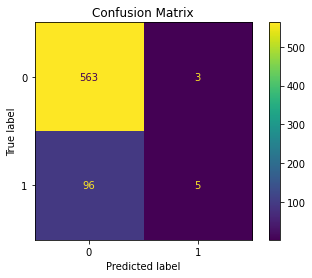

In [759]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

TP = 5, TN =563 , FP=3 , FN= 96. This confusion matrix shows that the model is able to predict negative non-churners more than non-churners.

In [760]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)

                  Feature  Coefficient
0       total day minutes     0.640393
8  customer service calls     0.592812
2       total eve minutes     0.279619
6      total intl minutes     0.278890
4     total night minutes     0.097260
3         total eve calls     0.032691
1         total day calls     0.002962
5       total night calls    -0.018568
7        total intl calls    -0.223304


In [761]:
#tuning the decision threshold to see which one has a better recall
from sklearn.metrics import recall_score

y_prob = model.predict_proba(X_test)[:, 1]

for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred = (y_prob > t).astype(int)
    print(f"Threshold {t} → Recall:", recall_score(y_test, y_pred))

Threshold 0.5 → Recall: 0.04950495049504951
Threshold 0.4 → Recall: 0.10891089108910891
Threshold 0.3 → Recall: 0.3069306930693069
Threshold 0.2 → Recall: 0.5841584158415841
Threshold 0.1 → Recall: 0.8613861386138614


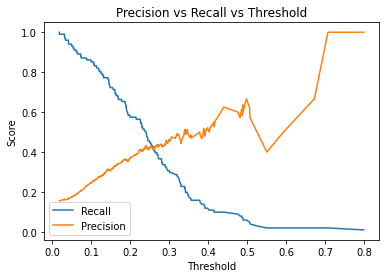

In [762]:
#creating a visualization to see where precision and recall are optimum
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, precision[:-1], label='Precision')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.show()

In [763]:
#use a decision threshold of 0.1
new_y_pred = (y_prob > 0.1).astype(int)

In [764]:
print(confusion_matrix(y_test, new_y_pred))
print(classification_report(y_test, new_y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[299 267]
 [ 14  87]]
              precision    recall  f1-score   support

           0       0.96      0.53      0.68       566
           1       0.25      0.86      0.38       101

    accuracy                           0.58       667
   macro avg       0.60      0.69      0.53       667
weighted avg       0.85      0.58      0.64       667

ROC-AUC: 0.7735542105447293


After using a decision threshold of 0.1, the recall score for churners increased while that of non-churners decreased.

To have a more balanced recall score for both churners and non-churners,a Random Forest Classifier would work best.

a random forest classifier is able to cater for non linear relationships.

In [765]:
#coming up with a random forest classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf > 0.3).astype(int)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

[[480  86]
 [ 27  74]]
              precision    recall  f1-score   support

           0       0.95      0.85      0.89       566
           1       0.46      0.73      0.57       101

    accuracy                           0.83       667
   macro avg       0.70      0.79      0.73       667
weighted avg       0.87      0.83      0.85       667

ROC-AUC: 0.875397963824651


A recall score of 0.85 for non churners and 0.73 for churners was achieved. This is more balanced and will ensure better prediction thus is a better model.


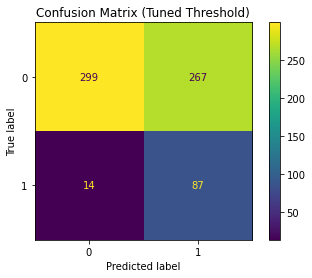

In [766]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, new_y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix (Tuned Threshold)")
plt.show()

TP=87, TN=299, FN=14, FP=267. The model is performing better given the results.

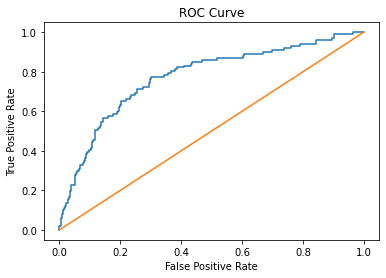

In [767]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

The ROC curve is more to the left which means the model is performing well.

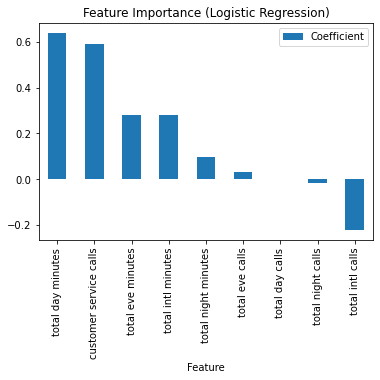

In [768]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coefficients.set_index('Feature').plot(kind='bar')
plt.title("Feature Importance (Logistic Regression)")
plt.show()

The above chart shows the importance of each feature in driving customer churn with total day minutes being the highest and total intl calls being the lowest.
